# 01 — BDD100K Dataset Exploration

This notebook explores the **BDD100K road-scene dataset** before training the YOLO object detection model.

### Objectives
- Inspect the dataset structure and annotations
- Explore automotive object classes
- Analyze class distribution
- Visualize ground-truth bounding boxes
- Select the classes required for the project

### Project Roadmap

**Dataset Exploration → Data Preparation → YOLO Training → Evaluation → Inference → Driving Risk Analysis**



## 1. Environment Setup

In [23]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
from collections import Counter
import random

## 2. Dataset Loading

In [3]:


DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset directory:", DATA_DIR.resolve())

Dataset directory: D:\Yasna-ML-Projects\Automotive-YOLO-Object-Detection\data


In [4]:
DATASET_ROOT = Path("../data/bdd100k")

print("Dataset root:", DATASET_ROOT.resolve())
print("Dataset exists:", DATASET_ROOT.exists())

print("\nContents:")
for item in DATASET_ROOT.iterdir():
    print("-", item.name)

Dataset root: D:\Yasna-ML-Projects\Automotive-YOLO-Object-Detection\data\bdd100k
Dataset exists: True

Contents:
- images
- labels


## 3. Dataset Structure

In [5]:
IMAGE_DIR = DATASET_ROOT / "images"
LABEL_DIR = DATASET_ROOT / "labels"

print("Images:")
for item in IMAGE_DIR.iterdir():
    print("-", item.name)

print("\nLabels:")
for item in LABEL_DIR.iterdir():
    print("-", item.name)

Images:
- 100k

Labels:
- test
- train
- val


In [10]:

    # Define the main dataset directories
IMAGE_100K_DIR = IMAGE_DIR / "100k"
TRAIN_LABEL_DIR = LABEL_DIR / "train"

# Get the available image splits
image_splits = [
    item.name for item in IMAGE_100K_DIR.iterdir()
    if item.is_dir()
]

# Get all training annotation files
train_label_files = list(TRAIN_LABEL_DIR.glob("*.json"))

print("Image splits:", image_splits)
print("Number of training annotation files:", len(train_label_files))

# Show only the first 5 annotation files
print("\nSample annotation files:")
for file in train_label_files[:5]:
    print("-", file.name)

Image splits: ['test', 'train', 'val']
Number of training annotation files: 70000

Sample annotation files:
- 0000f77c-6257be58.json
- 0000f77c-62c2a288.json
- 0000f77c-cb820c98.json
- 0001542f-5ce3cf52.json
- 0001542f-7c670be8.json


In [11]:
# Select one annotation file as a sample
sample_label_path = train_label_files[0]

# Load the JSON annotation
with open(sample_label_path, "r") as f:
    sample_annotation = json.load(f)

# Extract the first frame
frame = sample_annotation["frames"][0]

# Extract the first object
first_object = frame["objects"][0]

# Display only the important information
print("Image name:", sample_annotation["name"])
print("Timestamp:", frame["timestamp"])

print("\nFirst object:")
print("Category:", first_object["category"])
print("Bounding box:", first_object["box2d"])

print("\nScene:", sample_annotation["attributes"]["scene"])
print("Time of day:", sample_annotation["attributes"]["timeofday"])

Image name: 0000f77c-6257be58
Timestamp: 10000

First object:
Category: traffic light
Bounding box: {'x1': 1125.902264, 'y1': 133.184488, 'x2': 1156.978645, 'y2': 210.875445}

Scene: city street
Time of day: daytime


## 4. Dataset Statistics

In [9]:
# Dataset splits available in BDD100K
splits = ["train", "val", "test"]

# Count the number of images and annotation files in each split
for split in splits:
    # Count JPG images
    image_count = len(list((IMAGE_100K_DIR / split).glob("*.jpg")))

    # Count JSON annotation files
    label_count = len(list((LABEL_DIR / split).glob("*.json")))

    # Display the results
    print(f"{split.upper():5} | Images: {image_count:,} | Labels: {label_count:,}")

TRAIN | Images: 70,000 | Labels: 70,000
VAL   | Images: 10,000 | Labels: 10,000
TEST  | Images: 20,000 | Labels: 20,000


In [13]:

# Counter for storing the number of objects in each class
class_counts = Counter()

# Read all training annotation files
for label_path in train_label_files:
    with open(label_path, "r") as f:
        annotation = json.load(f)

    # Get all objects from the first frame
    objects = annotation["frames"][0]["objects"]

    # Count each object category
    for obj in objects:
        class_counts[obj["category"]] += 1

# Display class counts from highest to lowest
for category, count in class_counts.most_common():
    print(f"{category:15} : {count:,}")

car             : 714,121
lane/single white : 247,108
traffic sign    : 239,961
traffic light   : 186,301
lane/road curb  : 109,868
lane/crosswalk  : 108,284
person          : 91,435
area/drivable   : 64,050
area/alternative : 61,799
lane/double yellow : 37,519
truck           : 30,012
lane/single yellow : 20,220
bus             : 11,688
bike            : 7,227
lane/double white : 5,674
rider           : 4,522
motor           : 3,002
lane/single other : 249
train           : 136
lane/double other : 26
area/unknown    : 2


In [14]:
# BDD100K object detection classes used in this project
DETECTION_CLASSES = [
    "car",
    "truck",
    "bus",
    "train",
    "person",
    "rider",
    "bike",
    "motor",
    "traffic light",
    "traffic sign",
]

# Keep only object detection categories
detection_counts = {
    category: class_counts[category]
    for category in DETECTION_CLASSES
}

# Display object detection class distribution
for category, count in sorted(
    detection_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{category:15} : {count:,}")

car             : 714,121
traffic sign    : 239,961
traffic light   : 186,301
person          : 91,435
truck           : 30,012
bus             : 11,688
bike            : 7,227
rider           : 4,522
motor           : 3,002
train           : 136


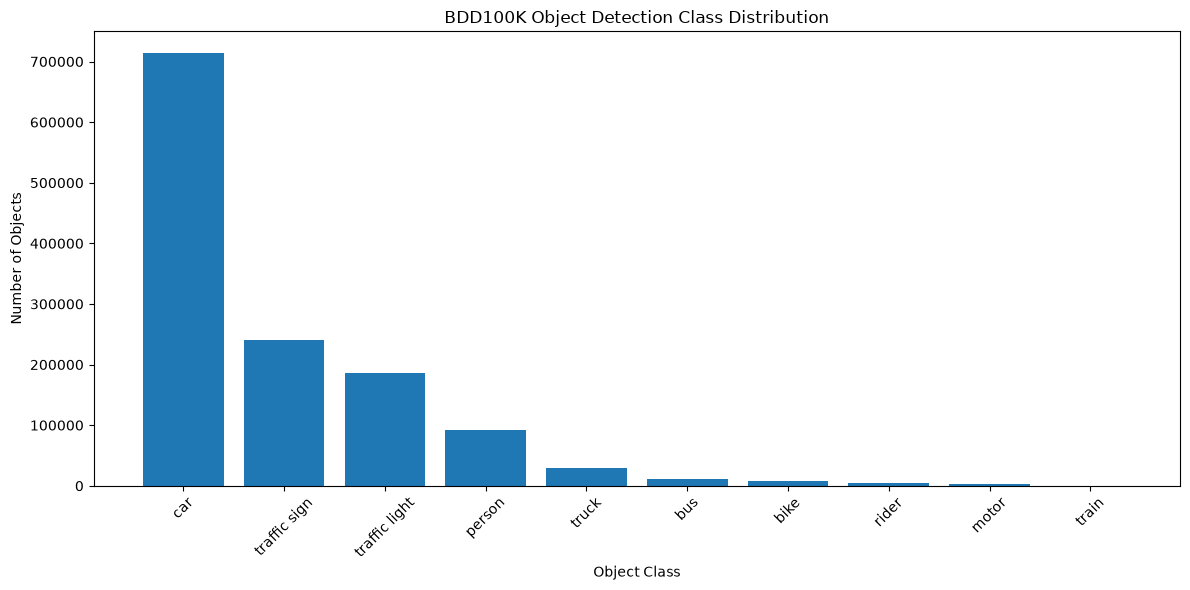

In [15]:
# Sort object detection classes by frequency
sorted_counts = dict(
    sorted(
        detection_counts.items(),
        key=lambda item: item[1],
        reverse=True
    )
)

# Create the class distribution bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    sorted_counts.keys(),
    sorted_counts.values()
)

# Add chart labels and title
plt.title("BDD100K Object Detection Class Distribution")
plt.xlabel("Object Class")
plt.ylabel("Number of Objects")

# Rotate class names for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5. Bounding Box Visualization

In [16]:
# Select one sample annotation file
sample_label_path = train_label_files[0]

# Get the corresponding image name
sample_image_name = sample_label_path.stem + ".jpg"

# Build the full image path
sample_image_path = IMAGE_100K_DIR / "train" / sample_image_name

# Load the annotation
with open(sample_label_path, "r") as f:
    annotation = json.load(f)

# Load the image
image = Image.open(sample_image_path)

# Get all objects from the first frame
objects = annotation["frames"][0]["objects"]

print("Image:", sample_image_path.name)
print("Number of annotated objects:", len(objects))

Image: 0000f77c-6257be58.jpg
Number of annotated objects: 11


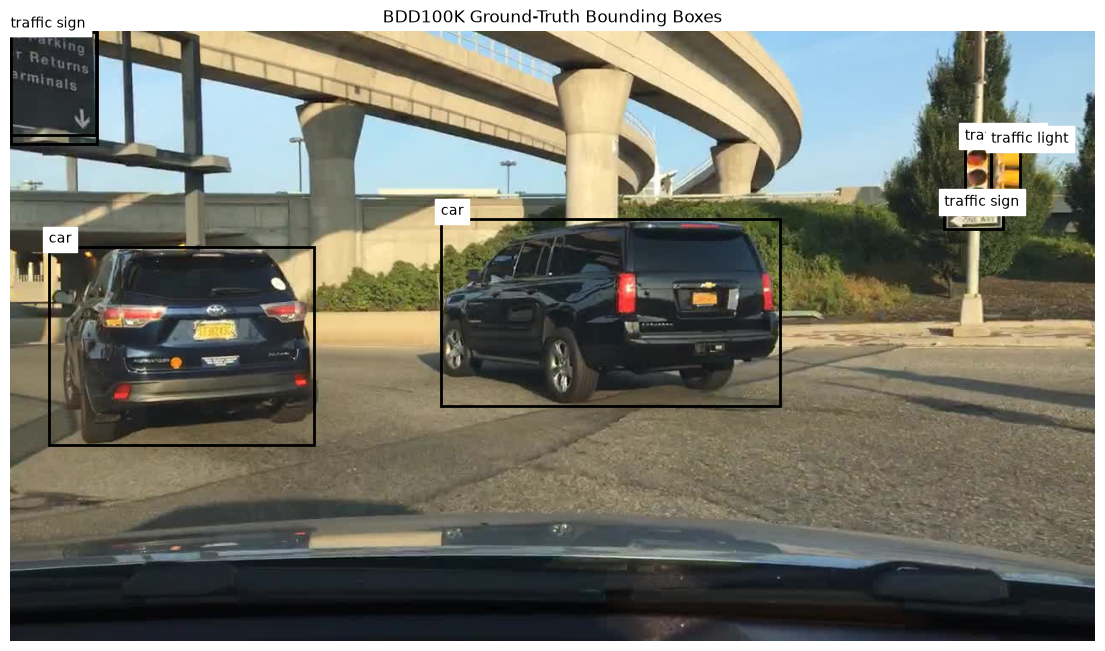

In [17]:
# Create a figure for visualization
plt.figure(figsize=(14, 8))

# Display the image
plt.imshow(image)

# Get the current plot axis
ax = plt.gca()

# Draw bounding boxes only for the object detection classes
for obj in objects:
    category = obj["category"]

    # Skip lane and drivable-area annotations
    if category not in DETECTION_CLASSES:
        continue

    # Get bounding box coordinates
    box = obj["box2d"]

    x1 = box["x1"]
    y1 = box["y1"]
    x2 = box["x2"]
    y2 = box["y2"]

    # Calculate box width and height
    width = x2 - x1
    height = y2 - y1

    # Draw the bounding box
    rectangle = plt.Rectangle(
        (x1, y1),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    # Add the object class name above the box
    ax.text(
        x1,
        y1 - 5,
        category,
        fontsize=10,
        backgroundcolor="white"
    )

# Remove axis numbers for cleaner visualization
plt.axis("off")

# Add a title
plt.title("BDD100K Ground-Truth Bounding Boxes")

plt.show()

In [18]:
# Show all annotation categories in the sample image
print("All annotations:")

for obj in objects:
    category = obj["category"]

    # Check whether this category is used for YOLO object detection
    if category in DETECTION_CLASSES:
        print(f"✓ {category:20} -> Detection")
    else:
        print(f"✗ {category:20} -> Ignored")

All annotations:
✓ traffic light        -> Detection
✓ traffic light        -> Detection
✓ traffic sign         -> Detection
✓ traffic sign         -> Detection
✓ car                  -> Detection
✓ car                  -> Detection
✓ traffic sign         -> Detection
✗ area/drivable        -> Ignored
✗ lane/road curb       -> Ignored
✗ lane/road curb       -> Ignored
✗ lane/road curb       -> Ignored


## 6. Environmental Attributes Analysis

In [19]:
from collections import Counter

# Counters for environmental attributes
timeofday_counts = Counter()
weather_counts = Counter()
scene_counts = Counter()

# Read all training annotation files
for label_path in train_label_files:
    with open(label_path, "r") as f:
        annotation = json.load(f)

    # Get image-level attributes
    attributes = annotation["attributes"]

    # Count each environmental category
    timeofday_counts[attributes["timeofday"]] += 1
    weather_counts[attributes["weather"]] += 1
    scene_counts[attributes["scene"]] += 1

# Display time-of-day distribution
print("Time of Day:")
for category, count in timeofday_counts.most_common():
    print(f"{category:15} : {count:,}")

# Display weather distribution
print("\nWeather:")
for category, count in weather_counts.most_common():
    print(f"{category:15} : {count:,}")

# Display scene distribution
print("\nScene:")
for category, count in scene_counts.most_common():
    print(f"{category:15} : {count:,}")

Time of Day:
daytime         : 36,800
night           : 28,028
dawn/dusk       : 5,033
undefined       : 139

Weather:
clear           : 37,412
overcast        : 8,784
undefined       : 8,134
snowy           : 5,571
rainy           : 5,083
partly cloudy   : 4,886
foggy           : 130

Scene:
city street     : 43,581
highway         : 17,414
residential     : 8,105
parking lot     : 378
undefined       : 366
tunnel          : 129
gas stations    : 27


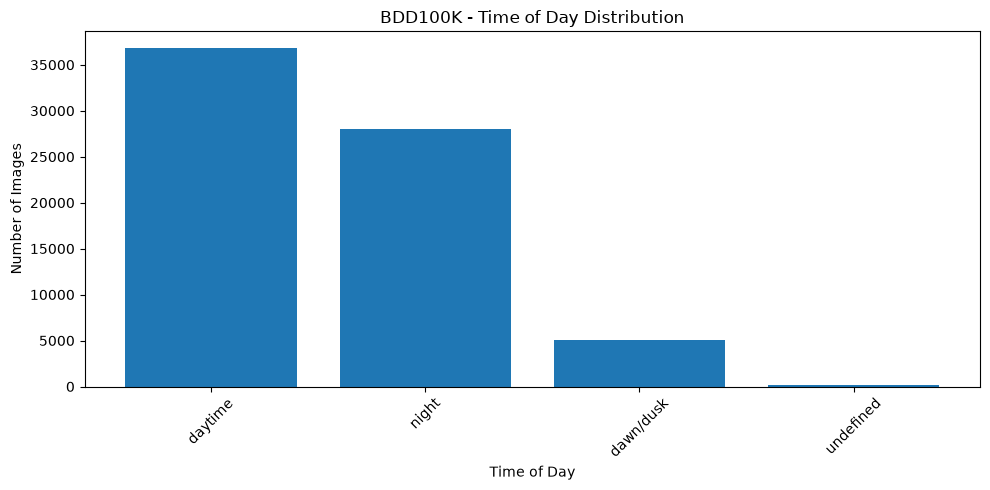

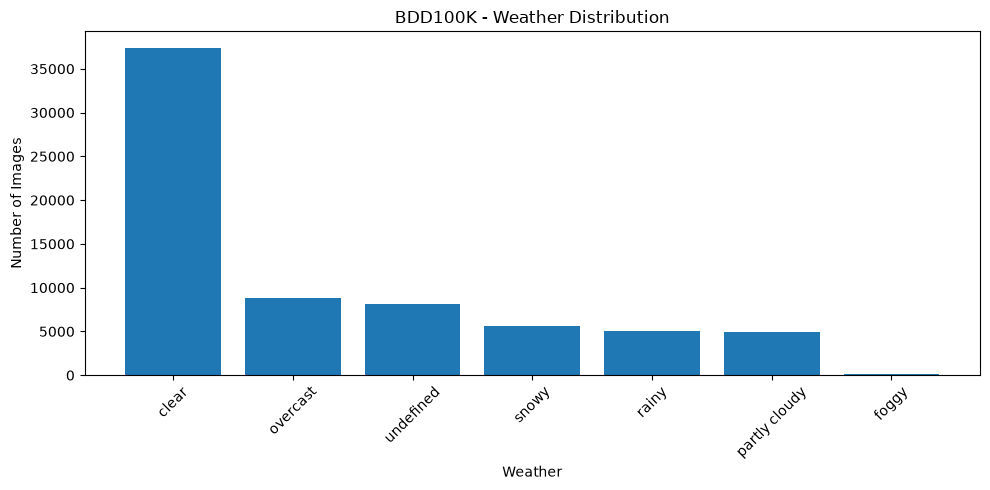

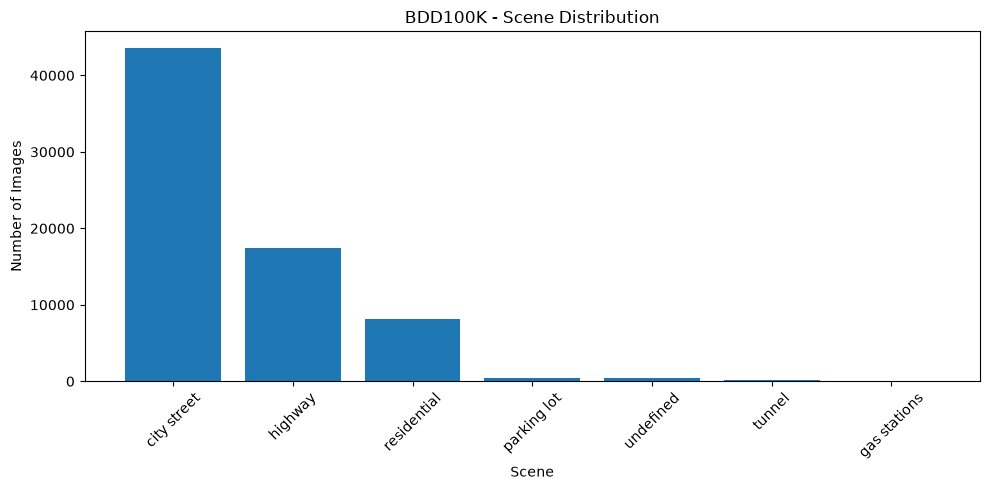

In [20]:
# Prepare environmental distributions for visualization
environmental_data = {
    "Time of Day": timeofday_counts,
    "Weather": weather_counts,
    "Scene": scene_counts
}

# Create one chart for each environmental attribute
for title, counts in environmental_data.items():

    # Sort categories from highest to lowest
    sorted_data = dict(
        sorted(
            counts.items(),
            key=lambda item: item[1],
            reverse=True
        )
    )

    # Create the bar chart
    plt.figure(figsize=(10, 5))

    plt.bar(
        sorted_data.keys(),
        sorted_data.values()
    )

    # Add title and labels
    plt.title(f"BDD100K - {title} Distribution")
    plt.xlabel(title)
    plt.ylabel("Number of Images")

    # Rotate labels for better readability
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## 7. Image Size Analysis

In [21]:
# Select a sample of training images
sample_images = list((IMAGE_100K_DIR / "train").glob("*.jpg"))[:1000]

# Store image dimensions
image_sizes = []

# Read the width and height of each sample image
for image_path in sample_images:
    with Image.open(image_path) as img:
        image_sizes.append(img.size)

# Count different image resolutions
size_counts = Counter(image_sizes)

# Display the detected resolutions
print("Image resolutions:")

for size, count in size_counts.most_common():
    width, height = size
    print(f"{width} x {height} : {count:,} images")

Image resolutions:
1280 x 720 : 1,000 images


## 8. Random Sample Visualization

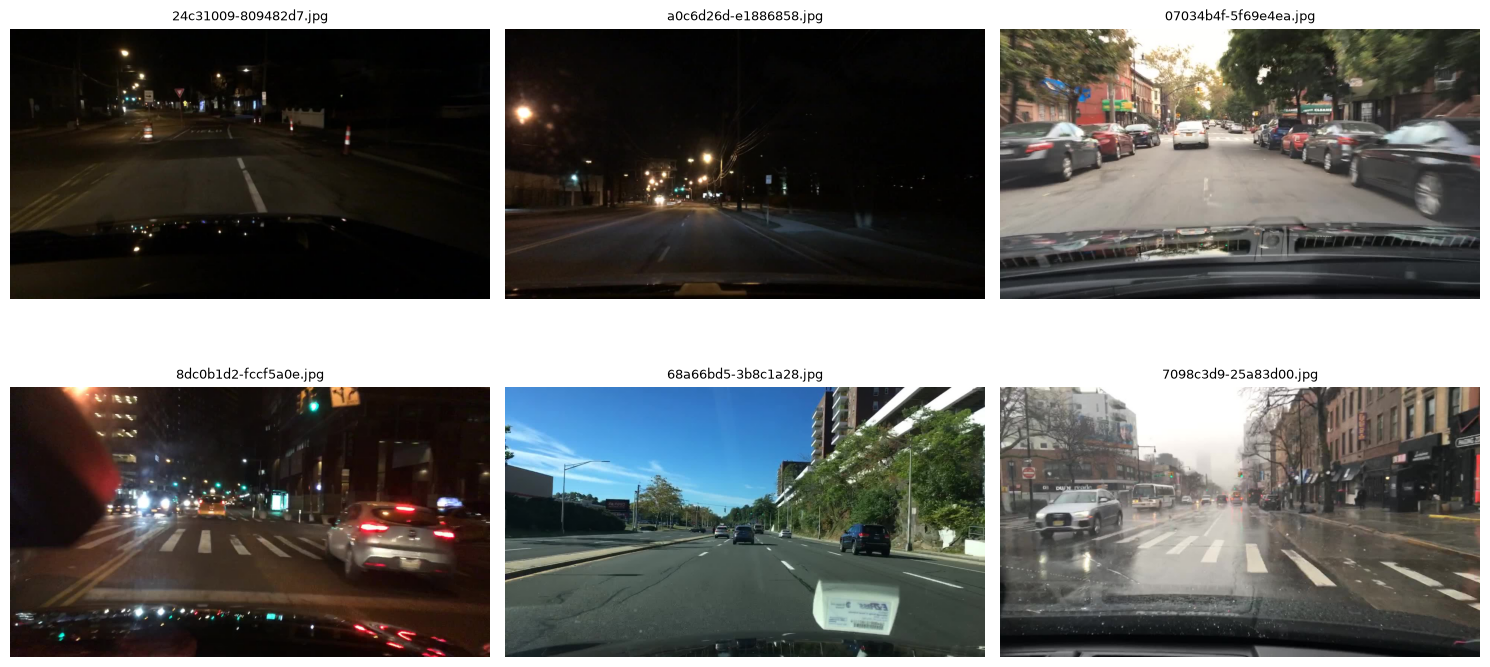

In [24]:


# Get all training image paths
train_images = list((IMAGE_100K_DIR / "train").glob("*.jpg"))

# Randomly select 6 images
random_samples = random.sample(train_images, 6)

# Create a figure to display the images
plt.figure(figsize=(15, 8))

# Display each selected image
for i, image_path in enumerate(random_samples):

    # Load the image
    with Image.open(image_path) as img:

        # Create a position in the 2x3 grid
        plt.subplot(2, 3, i + 1)

        # Display the image
        plt.imshow(img)

        # Show the image filename
        plt.title(image_path.name, fontsize=9)

        # Hide axis values
        plt.axis("off")

# Adjust spacing between images
plt.tight_layout()

# Display the final grid
plt.show()

## 9. Conclusion

- BDD100K contains 100,000 annotated road images.
- The dataset includes 10 object-detection classes with significant class imbalance.
- Training data covers diverse day/night, weather, and driving scenarios.
- Images have a resolution of 1280 × 720.
- The dataset is ready for YOLO data preparation and format conversion.